# HomeWork2 Дуркин Макар

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

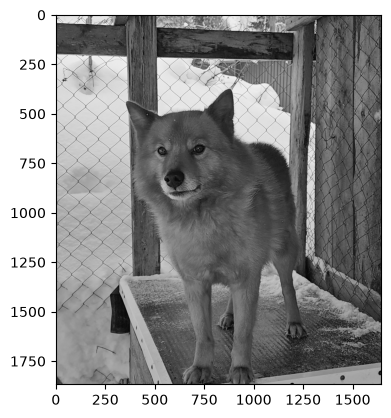

In [3]:
image = cv2.imread('Dog_Color.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

## 1. Зашумление изображения при помощи шума гаусса, постоянного шума

### Шум Гаусса

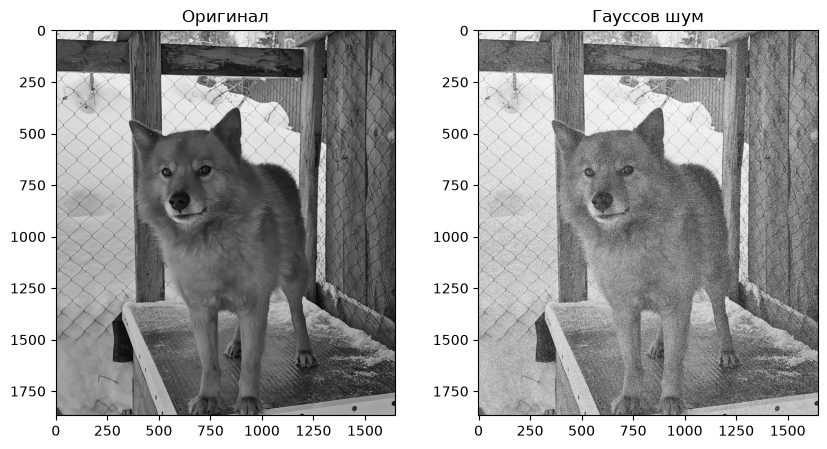

In [8]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(image_gray, cmap="gray"); plt.title("Оригинал")
plt.subplot(1, 2, 2); plt.imshow(image_noise_gauss, cmap="gray"); plt.title("Гауссов шум")
plt.show()

### Постоянный шум

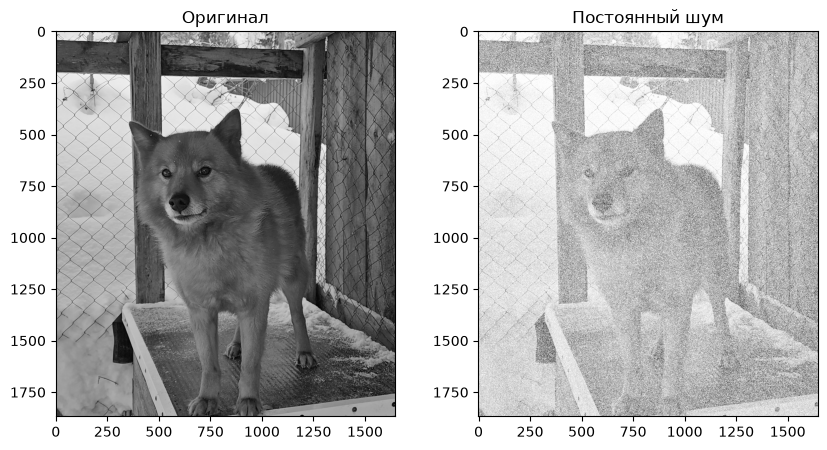

In [4]:
np.random.seed(53)

noise_uniform = np.random.randint(-50, 51, size=image_gray.shape, dtype=int)
image_sp = cv2.add(image_gray, noise_uniform.astype(np.uint8))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(image_gray, cmap="gray"); plt.title("Оригинал")
plt.subplot(1, 2, 2); plt.imshow(image_sp, cmap="gray"); plt.title("Постоянный шум")
plt.show()

## 2. Тестирование медианного фильтра, фильтра гаусса, билатерального фильтра, фильтра нелокальных средних с различными параметрами

### Вспомогательная функция сбора данных

In [5]:
def evaluate(original, filtered, name):
    mse = mean_squared_error(original, filtered)
    ssim, _ = structural_similarity(original, filtered, full=True)
    print(f"{name:40s} | MSE = {mse:8.2f} | SSIM = {ssim:.4f}")
    return filtered, (mse, ssim)

### Фильтры

In [6]:
def run_all_filters(noisy_image, results, name_image):

    print(name_image + " --->")
    print()
    
    # Медианный фильтр
    for k in [3, 5, 7]:
        f = cv2.medianBlur(noisy_image, k)
        results[f"Median k={k}"] = evaluate(image_gray, f, f"Median k={k}")

    # Фильтр Гаусса
    for k in [3, 5, 7]:
        for sigma in [0.5, 1.0, 2.0]:
            f = cv2.GaussianBlur(noisy_image, (k, k), sigma)
            results[f"Gaussian k={k}, s={sigma}"] = evaluate(
                image_gray, f, f"Gaussian k={k}, s={sigma}"
            )

    # Билатеральный фильтр
    for d in [5, 9, 15]:
        for sc in [30, 75, 150]:
            f = cv2.bilateralFilter(noisy_image, d, sc, sc)
            results[f"Bilateral d={d}, s={sc}"] = evaluate(
                image_gray, f, f"Bilateral d={d}, s={sc}"
            )

    # Фильтр нелокальных средних
    for h in [5, 10, 20, 30]:
        f = cv2.fastNlMeansDenoising(noisy_image, None, h, 7, 21)
        results[f"NLM h={h}"] = evaluate(image_gray, f, f"NLM h={h}")


### Прогонка

In [11]:
results_gauss = {}
results_sp = {}

run_all_filters(image_noise_gauss, results_gauss, "Gauss")
print()
run_all_filters(image_sp, results_sp, "Uniform")

Gauss --->

Median k=3                               | MSE =   847.60 | SSIM = 0.3419
Median k=5                               | MSE =   510.16 | SSIM = 0.4786
Median k=7                               | MSE =   482.60 | SSIM = 0.5195
Gaussian k=3, s=0.5                      | MSE =  2116.13 | SSIM = 0.2394
Gaussian k=3, s=1.0                      | MSE =  1492.83 | SSIM = 0.4196
Gaussian k=3, s=2.0                      | MSE =  1467.51 | SSIM = 0.4353
Gaussian k=5, s=0.5                      | MSE =  2116.13 | SSIM = 0.2394
Gaussian k=5, s=1.0                      | MSE =  1413.68 | SSIM = 0.4838
Gaussian k=5, s=2.0                      | MSE =  1363.52 | SSIM = 0.5665
Gaussian k=7, s=0.5                      | MSE =  2116.13 | SSIM = 0.2394
Gaussian k=7, s=1.0                      | MSE =  1408.02 | SSIM = 0.4898
Gaussian k=7, s=2.0                      | MSE =  1360.22 | SSIM = 0.6060
Bilateral d=5, s=30                      | MSE =  2900.57 | SSIM = 0.1908
Bilateral d=5, s=75       

## 3. Выбор лучшего результата

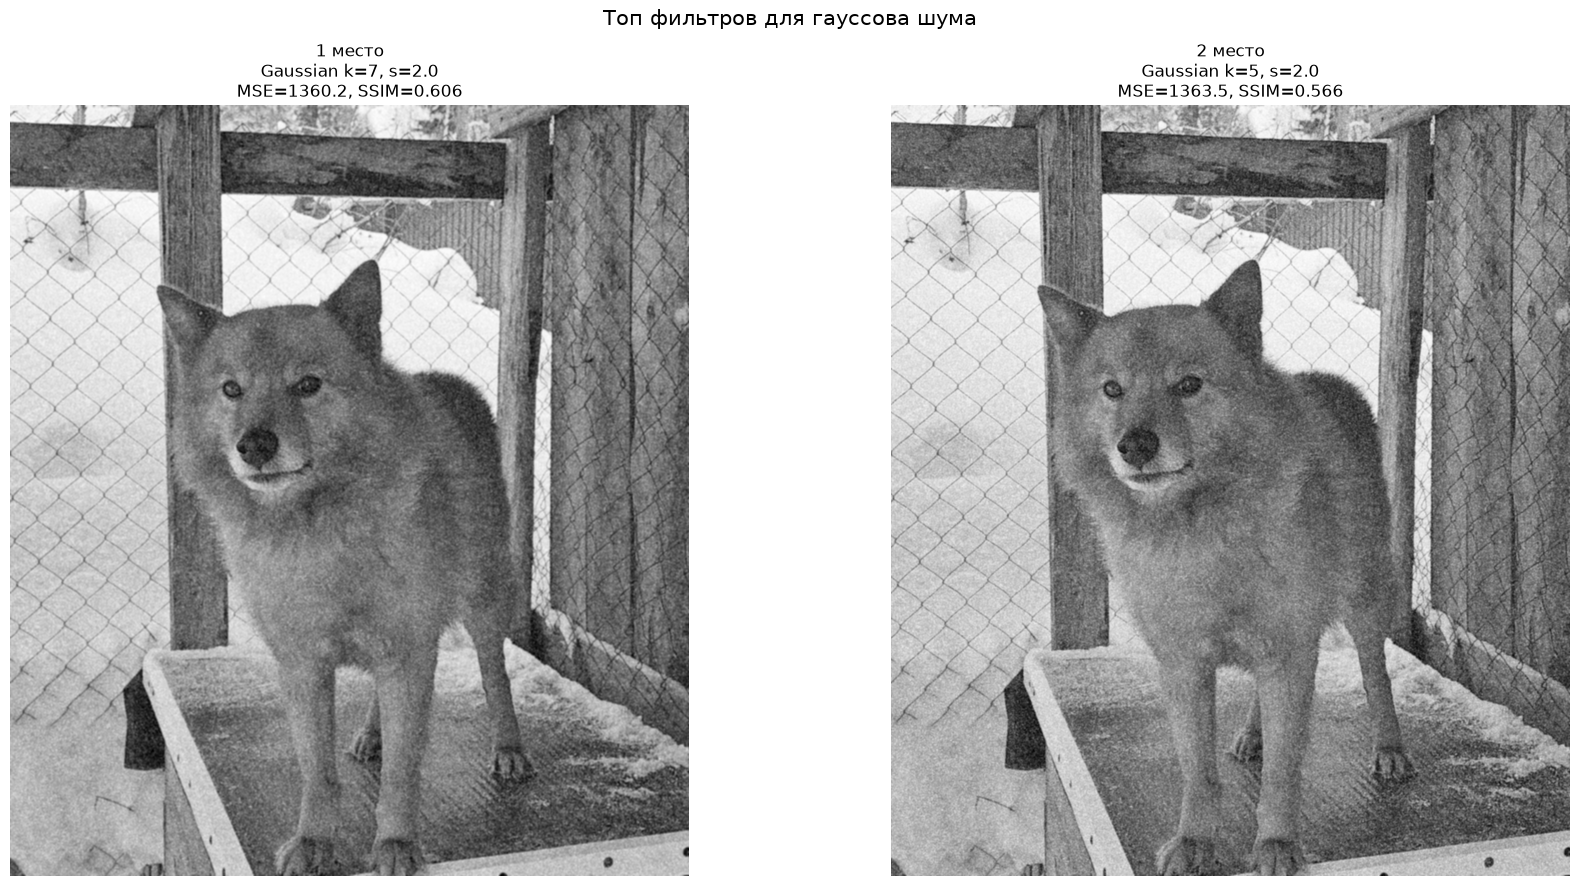

Лучший: Gaussian k=7, s=2.0 | MSE = 1360.22, SSIM = 0.6060



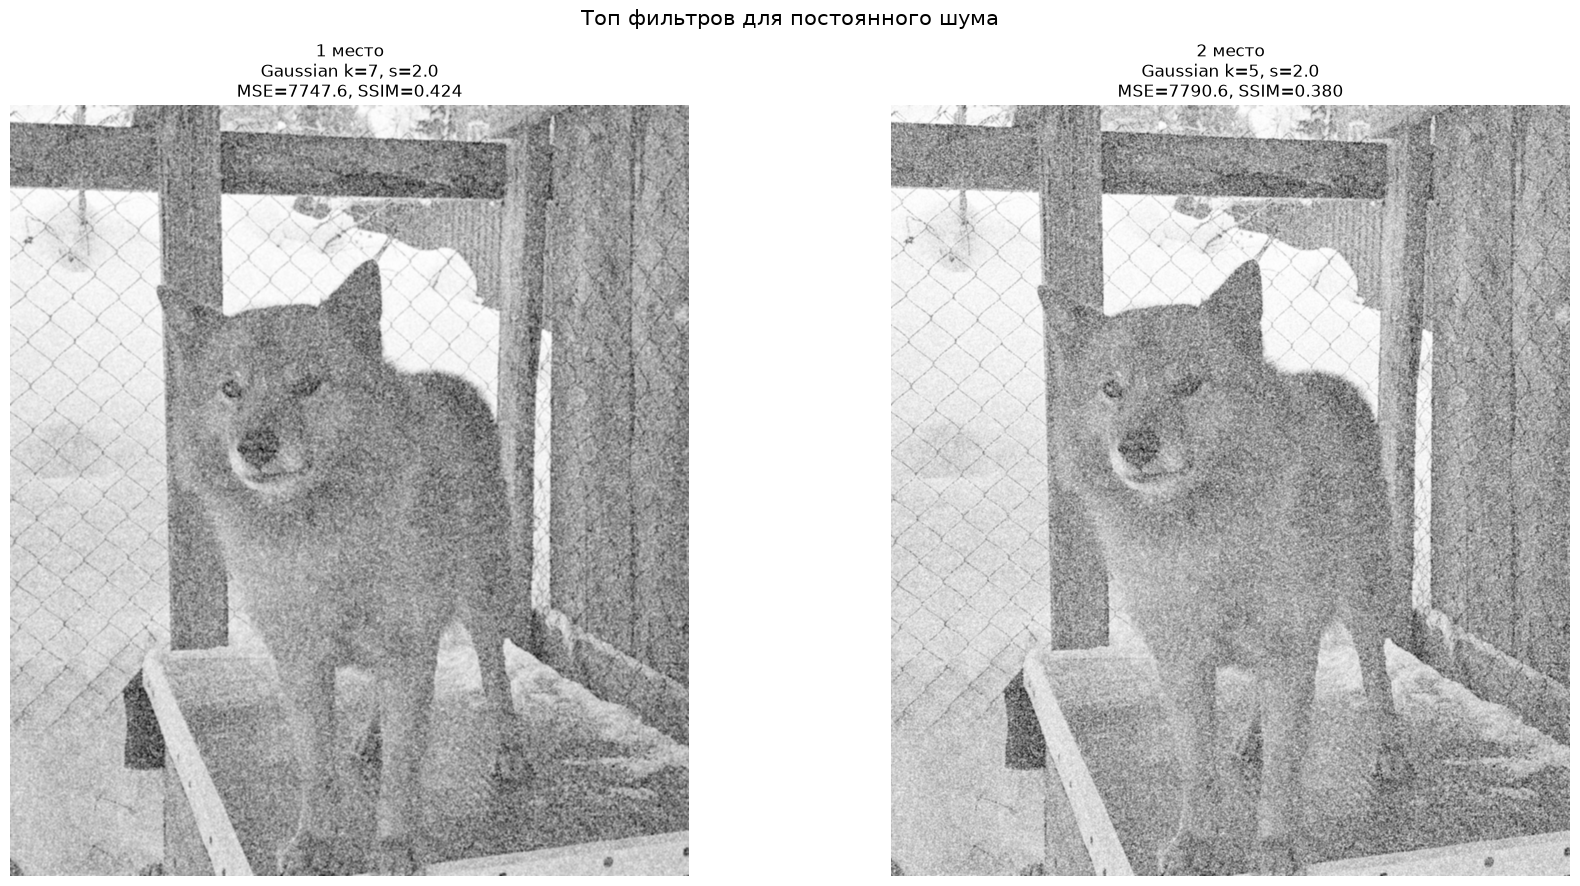

Лучший: Gaussian k=7, s=2.0 | MSE = 7747.62, SSIM = 0.4240



In [10]:
def show_top(results, title, n=2):
    top = sorted(results.items(), key=lambda x: x[1][1][1], reverse=True)[:n]

    plt.figure(figsize=(18, 9))
    for i, (name, (img, (mse, ssim))) in enumerate(top):
        plt.subplot(1, 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{i + 1} место\n{name}\nMSE={mse:.1f}, SSIM={ssim:.3f}")
        plt.axis("off")
    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

    best_name, (_, (bmse, bssim)) = max(results.items(), key=lambda x: x[1][1][1])
    print(f"Лучший: {best_name} | MSE = {bmse:.2f}, SSIM = {bssim:.4f}\n")

show_top(results_gauss, "Топ фильтров для гауссова шума")
show_top(results_sp, "Топ фильтров для постоянного шума")